In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Imputacja
from sklearn.impute import SimpleImputer, KNNImputer

# Skalowanie
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Outlier detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Klasyfikator bazowy do oceny
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    classification_report,
)

print("Biblioteki załadowane.")

Biblioteki załadowane.


In [2]:
from ucimlrepo import fetch_ucirepo

polish_companies_bankruptcy = fetch_ucirepo(id=365)

X = polish_companies_bankruptcy.data.features
y = polish_companies_bankruptcy.data.targets

- check number of companies in each year

In [3]:
X.head()

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A55,A56,A57,A58,A59,A60,A61,A62,A63,A64
0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,...,348690.0,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277
1,1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,...,2304.6,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870
2,1,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,...,6332.7,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078
3,1,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,...,20545.0,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497
4,1,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,...,3186.6,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980


In [4]:
y.head()

,class
0,0
1,0
2,0
3,0
4,0


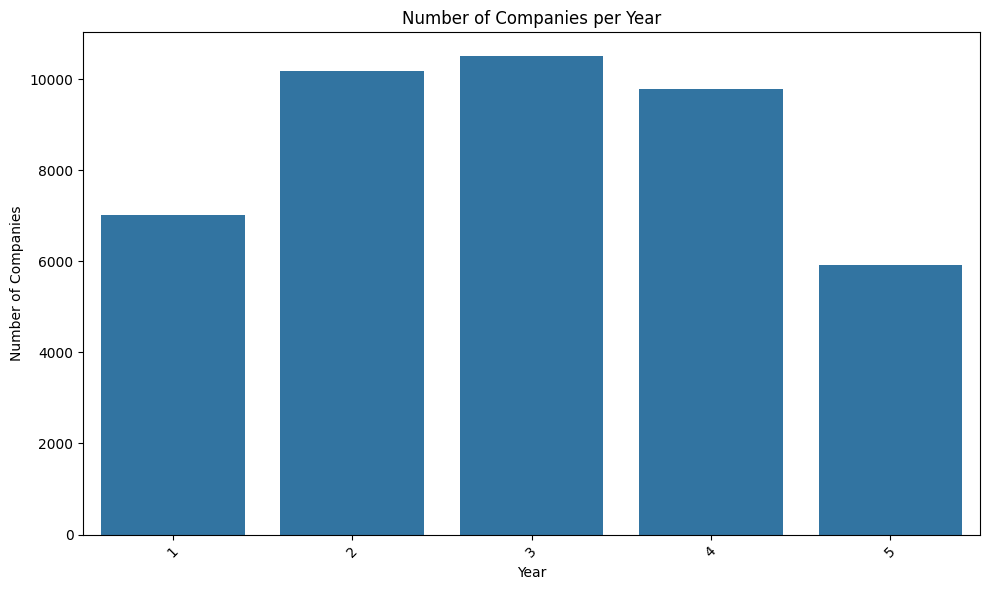

In [5]:
years = X["year"].unique()
counts = X["year"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=years, y=counts.values)
plt.title("Number of Companies per Year")
plt.xlabel("Year")
plt.ylabel("Number of Companies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- filter data for 3 only

In [6]:
mask_2010 = X["year"] == 3

X = X[mask_2010].drop(columns=["year"])
y = y[mask_2010]

In [7]:
X["class"] = y

In [8]:
X.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
count,10503.000000,10503.000000,10503.000000,10485.000000,1.047800e+04,10503.000000,10503.000000,10489.000000,10500.000000,10503.000000,...,10460.000000,10503.000000,10474.000000,10503.000000,9.911000e+03,10486.000000,1.046000e+04,10485.000000,10275.000000,10503.000000
mean,0.052844,0.619911,0.095490,9.980499,-1.347355e+03,-0.121159,0.065624,19.140113,1.819254,0.366093,...,-0.530082,-0.014817,3.848794,1.429319,5.713958e+02,13.935361,1.348668e+02,9.095149,35.766800,0.047129
std,0.647797,6.427041,6.420056,523.691951,1.185517e+05,6.970625,0.651152,717.756745,7.581659,6.428603,...,55.978608,18.684047,190.201224,77.273270,3.715816e+04,83.704103,2.600764e+04,31.419096,428.298315,0.211926
min,-17.692000,0.000000,-479.730000,0.002080,-1.190000e+07,-508.120000,-17.692000,-2.081800,-1.215700,-479.730000,...,-5691.700000,-1667.300000,-198.690000,-172.070000,0.000000e+00,-6.590300,-2.340000e+06,-0.000156,-0.000102,0.000000
25%,0.000686,0.253955,0.017461,1.040100,-5.207075e+01,0.000000,0.002118,0.431270,1.011275,0.297340,...,0.005137,0.006796,0.875560,0.000000,5.533150e+00,4.486075,4.073700e+01,3.062800,2.023350,0.000000
50%,0.043034,0.464140,0.198560,1.605600,1.579300e+00,0.000000,0.050945,1.111000,1.199000,0.515500,...,0.051765,0.106880,0.953060,0.002976,9.952100e+00,6.677300,7.066400e+01,5.139200,4.059300,0.000000
75%,0.123805,0.689330,0.419545,2.959500,5.608400e+01,0.072584,0.142275,2.857100,2.059100,0.725635,...,0.130010,0.271310,0.995927,0.240320,2.093600e+01,10.587500,1.182200e+02,8.882600,9.682750,0.000000
max,52.652000,480.730000,17.708000,53433.000000,6.850000e+05,45.533000,52.652000,53432.000000,740.440000,11.837000,...,293.150000,552.640000,18118.000000,7617.300000,3.660000e+06,4470.400000,1.070000e+06,1974.500000,21499.000000,1.000000


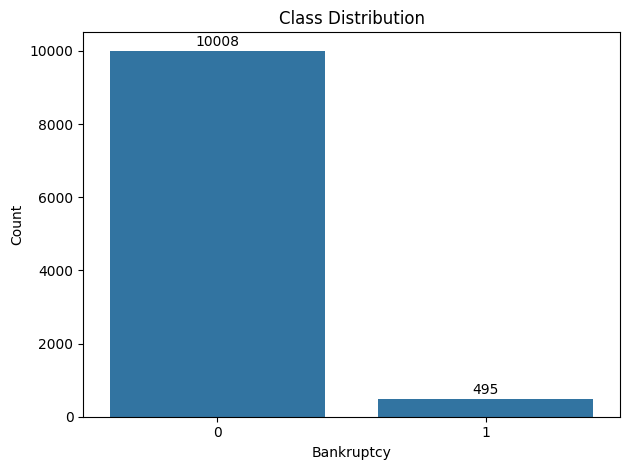

In [9]:
sns.countplot(data=y, x="class")
plt.title("Class Distribution")
plt.xlabel("Bankruptcy")
plt.ylabel("Count")
ax = plt.gca()
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 1),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

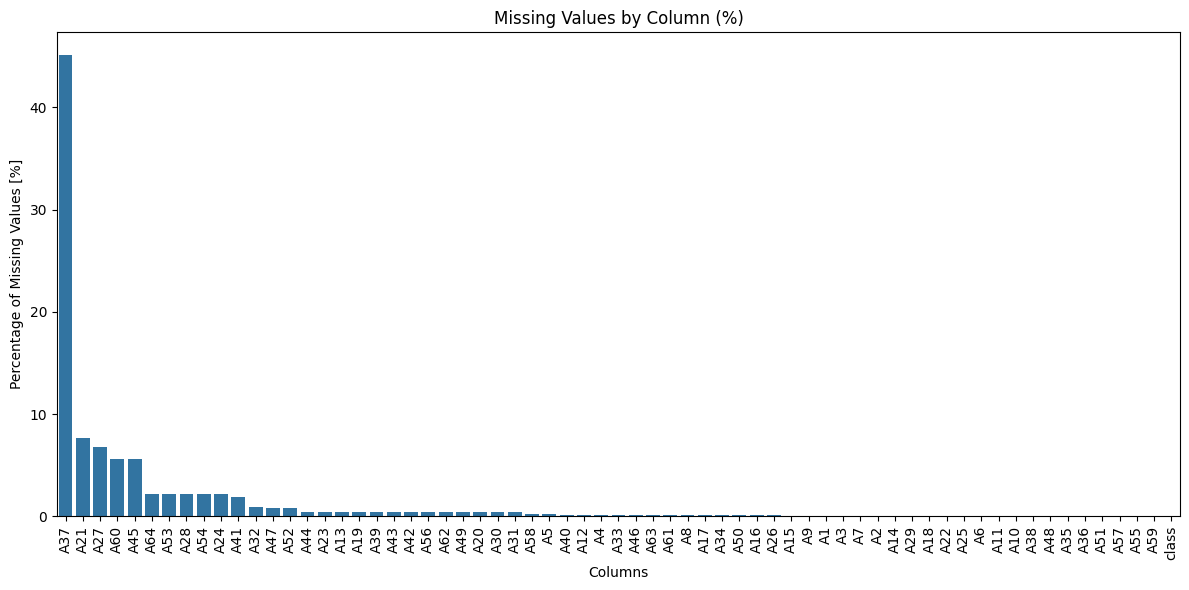

In [10]:
missing_values = X.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_values / len(X)) * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=missing_pct.index, y=missing_pct.values)
plt.xticks(rotation=90)
plt.title("Missing Values by Column (%)")
plt.xlabel("Columns")
plt.ylabel("Percentage of Missing Values [%]")
plt.tight_layout()
plt.show()

In [11]:
X = X.drop(columns=["A37"])

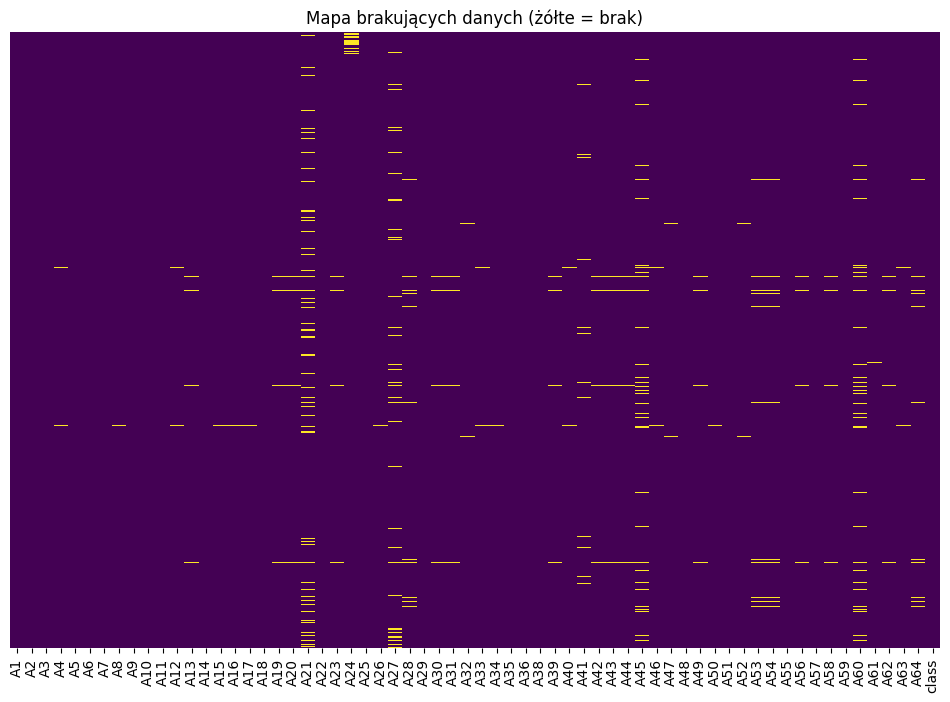

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Mapa brakujących danych (żółte = brak)")
plt.show()

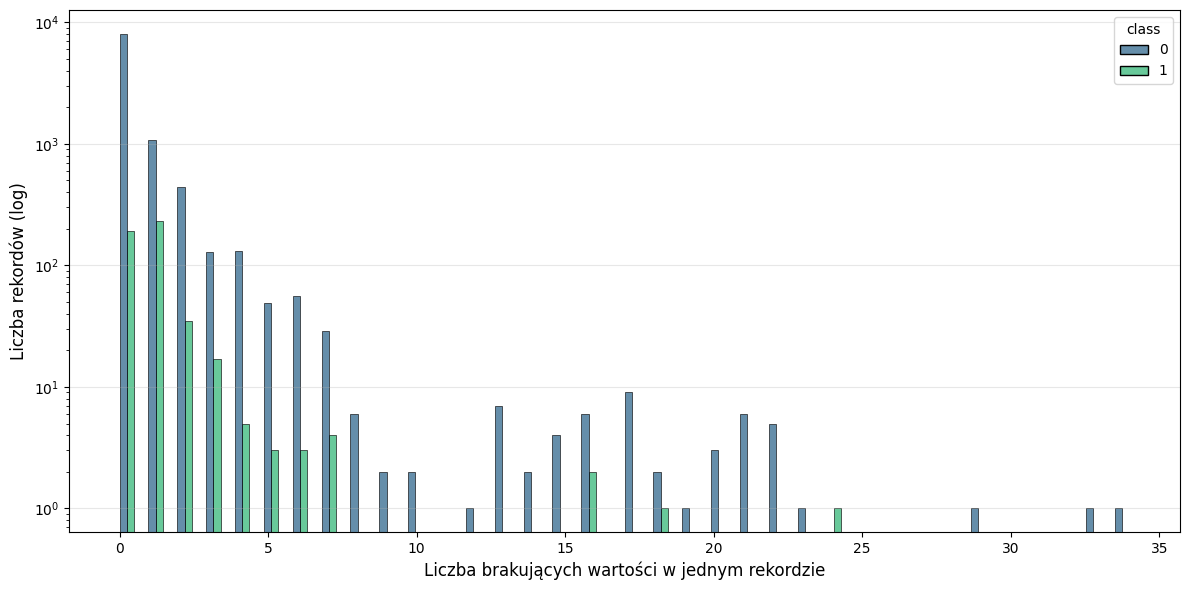

In [13]:
X["missing_count"] = X.drop(columns=["class"]).isnull().sum(axis=1)

plt.figure(figsize=(12, 6))

sns.histplot(
    data=X,
    x="missing_count",
    hue="class",
    bins=70,
    kde=False,
    palette="viridis",
    multiple="dodge",
)

plt.xlabel("Liczba brakujących wartości w jednym rekordzie", fontsize=12)
plt.ylabel("Liczba rekordów (log)", fontsize=12)

plt.yscale("log")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

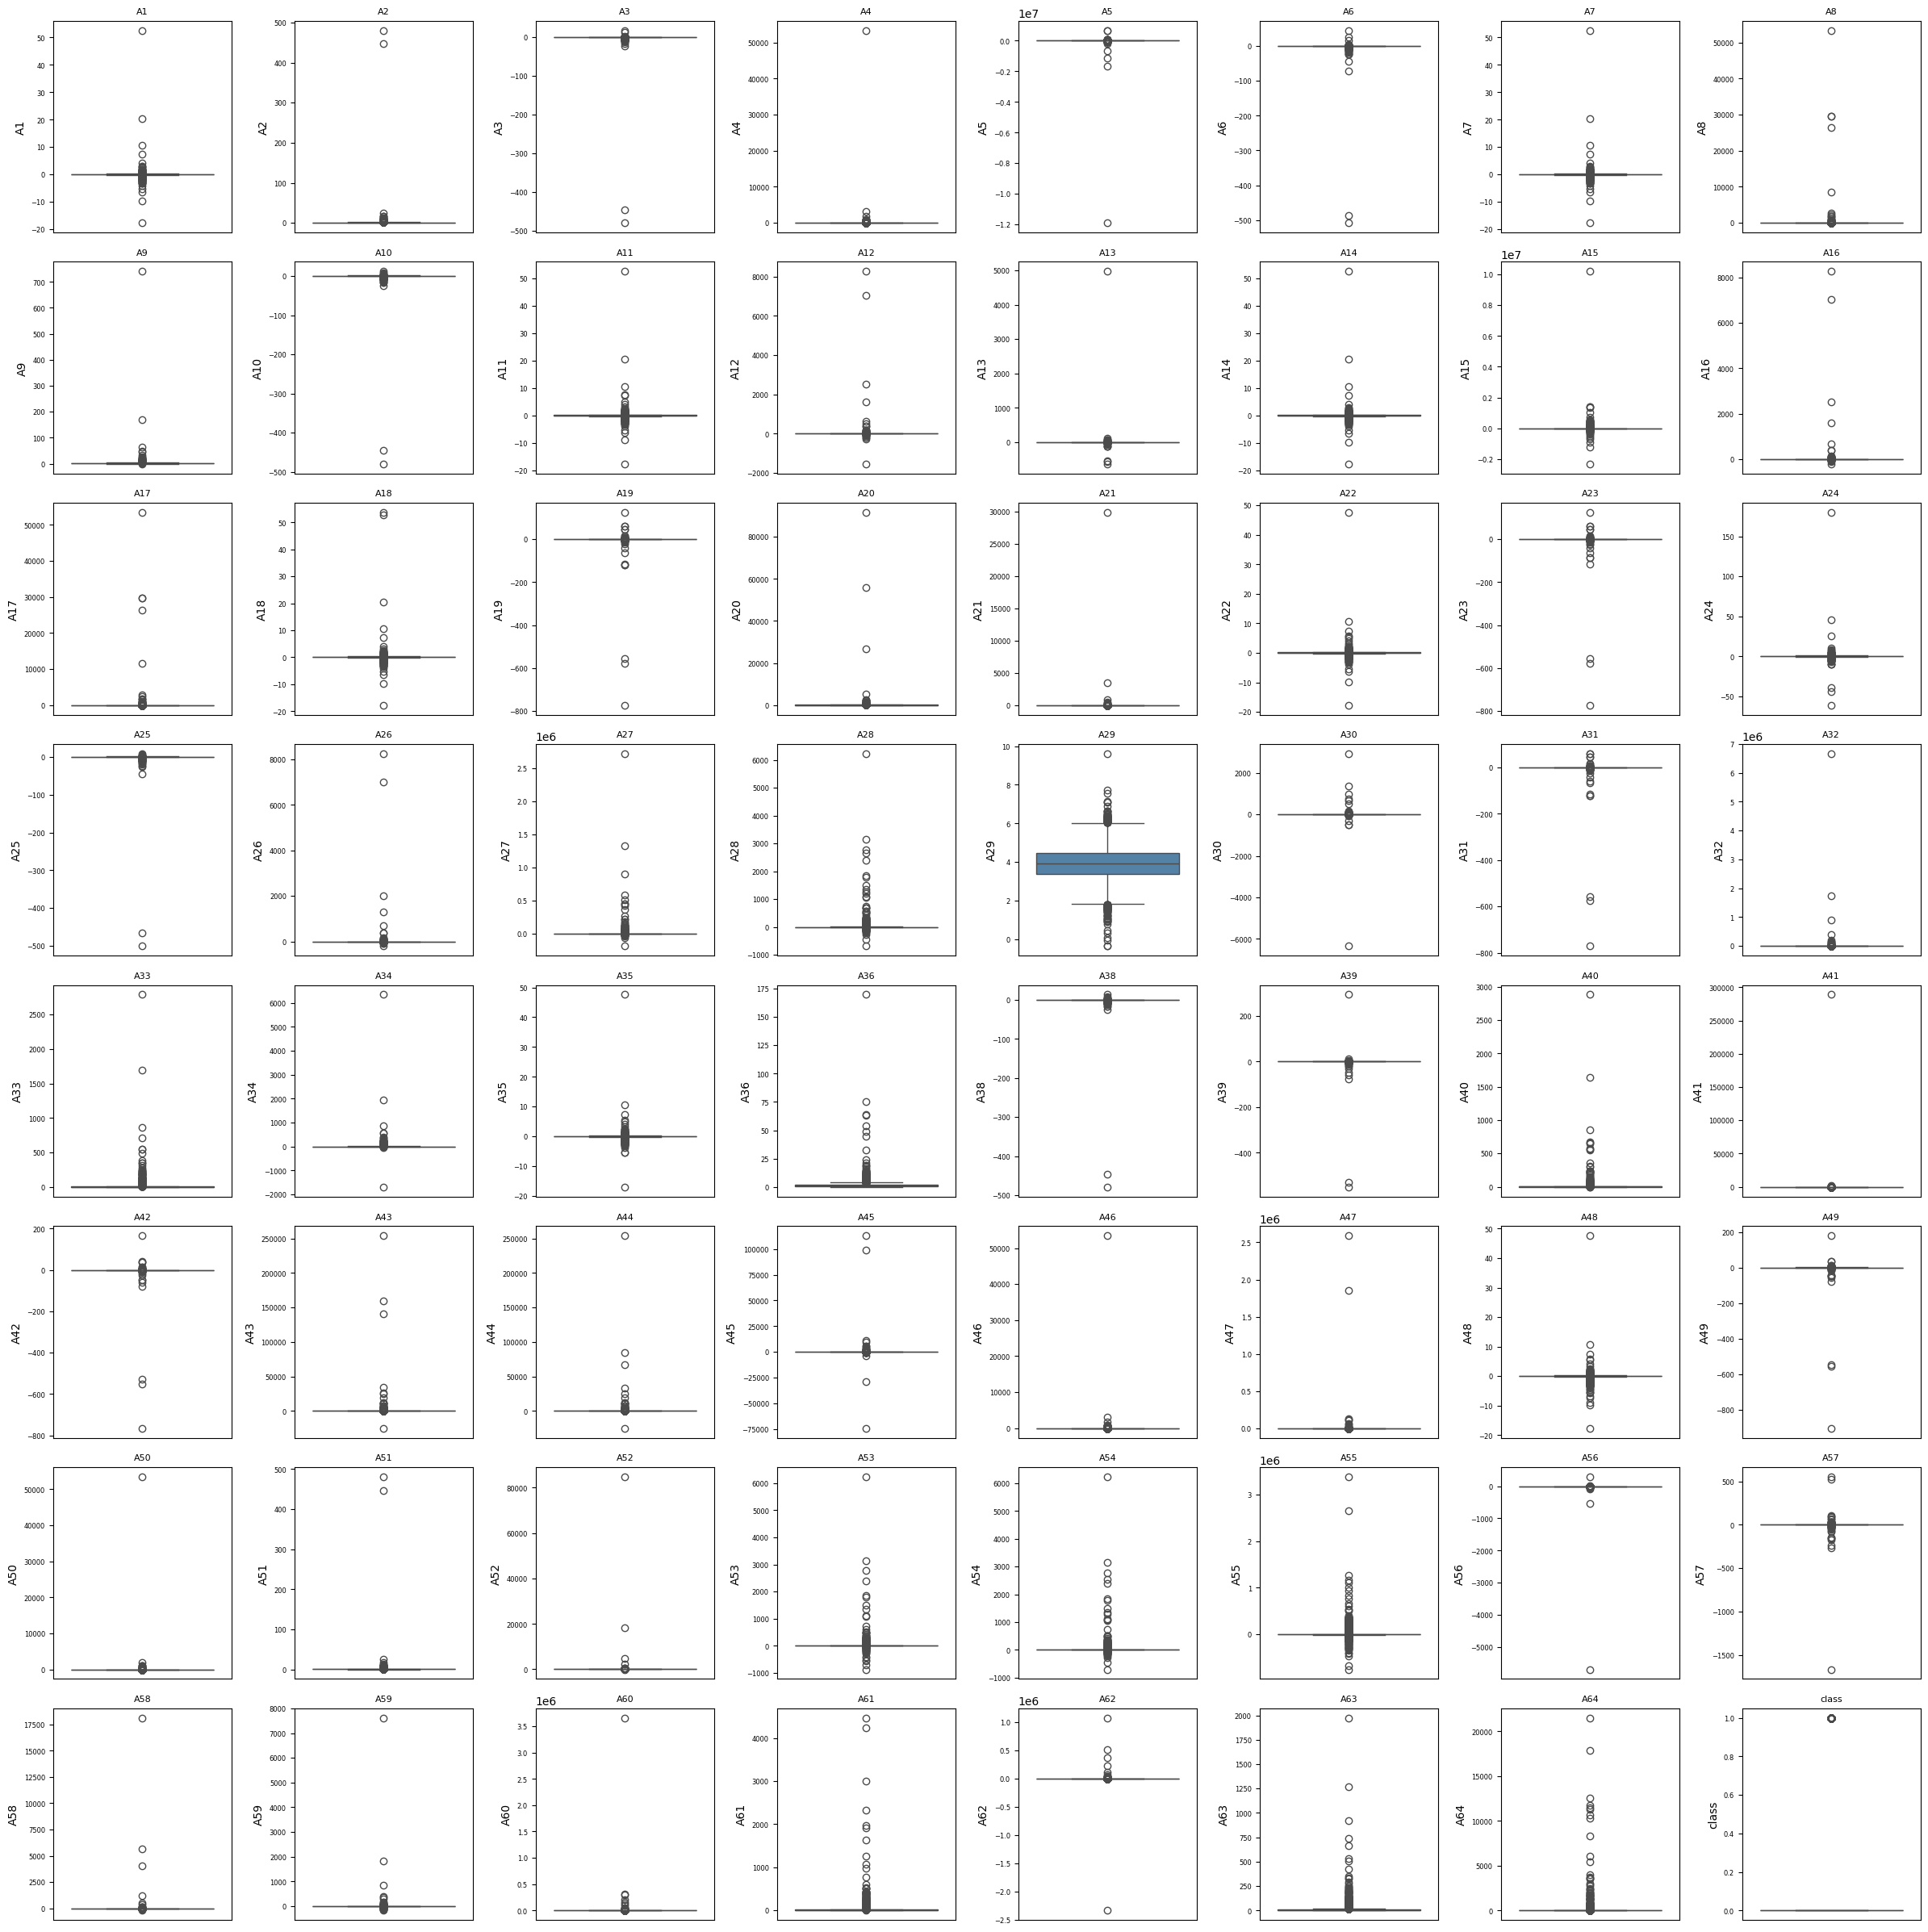

In [15]:
X = X.drop(columns=["missing_count"])
cols = X.columns
n_cols = 8
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(n_cols * 3, n_rows * 3))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=X[col], color="steelblue")
    plt.title(col, fontsize=8)
    plt.xticks([])
    plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()

___

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.pipeline import Pipeline

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X.drop(columns=["class"]),
    X["class"],
    test_size=0.2,
    stratify=X["class"],
    random_state=42,
)

In [18]:
proportion_train = y_train.value_counts(normalize=True).sort_index()
proportion_test = y_test.value_counts(normalize=True).sort_index()

comparison = pd.concat(
    [proportion_train.rename("train"), proportion_test.rename("test")], axis=1
).fillna(0)

comparison["diff_pp"] = (comparison["train"] - comparison["test"]) * 100

print("Porównanie proporcji klas")
print((comparison * 100).round(2))

max_diff = comparison["diff_pp"].abs().max()

Porównanie proporcji klas
       train   test  diff_pp
class                       
0      95.29  95.29    -0.11
1       4.71   4.71     0.11


___

In [19]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.nanpercentile(X, 25, axis=0)
        Q3 = np.nanpercentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.k * IQR
        self.upper_ = Q3 + self.k * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)


class PassthroughTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.n_features_in_ = np.array(X).shape[1]
        return self

    def transform(self, X, y=None):
        return np.array(X, dtype=float)


In [20]:
IMPUTERS = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "knn": KNNImputer(n_neighbors=5),
}

OUTLIERS = {"none": PassthroughTransformer(), "IQR_clip": IQRClipper(k=1.5)}

SCALERS = {
    "none": PassthroughTransformer(),
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}

MODELS = {
    "logistic_regression": LogisticRegression(random_state=42),
    "decision_tree": DecisionTreeClassifier(random_state=42),
}

In [21]:
from itertools import product
import copy
from tqdm import tqdm

In [22]:
# Ensure split exists even if this cell is run independently.
if not all(name in globals() for name in ["X_train", "X_test", "y_train", "y_test"]):
    X_train, X_test, y_train, y_test = train_test_split(
        X.drop(columns=["class"]),
        X["class"],
        test_size=0.2,
        stratify=X["class"],
        random_state=42,
    )

results = []
transformed_data = {}
total = len(IMPUTERS) * len(OUTLIERS) * len(SCALERS) * len(MODELS)
i = 0

for imp_name, out_name, scale_name, model_name in tqdm(
    product(IMPUTERS.keys(), OUTLIERS.keys(), SCALERS.keys(), MODELS.keys()),
    total=total,
):
    label = f"{imp_name} | {out_name} | {scale_name} | {model_name}"
    i += 1

    preprocess = Pipeline(
        [
            ("imputer", copy.deepcopy(IMPUTERS[imp_name])),
            ("outlier", copy.deepcopy(OUTLIERS[out_name])),
            ("scaler", copy.deepcopy(SCALERS[scale_name])),
        ]
    )

    X_tr = preprocess.fit_transform(X_train, y_train)
    X_te = preprocess.transform(X_test)

    transformed_data[label] = (X_tr, X_te)
    model = copy.deepcopy(MODELS[model_name])
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    row = {
        "label": label,
        "imputer": imp_name,
        "outlier": out_name,
        "scaler": scale_name,
        "model": model_name,
        "accuracy_score": accuracy_score(y_test, y_pred),
        "precision_score": precision_score(y_test, y_pred, zero_division=0),
        "recall_score": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc_score": roc_auc_score(y_test, y_prob),
        "conf_matrix": classification_report(y_test, y_pred, output_dict=True),
        "X_train_transformed": X_tr,
        "X_test_transformed": X_te,
    }
    results.append(row)

  0%|          | 0/48 [00:00<?, ?it/s]

100%|██████████| 48/48 [02:12<00:00,  2.77s/it]


In [35]:
from scipy.stats import gaussian_kde

_nan = X_train.isna().mean()
_q1 = X_train.quantile(0.25);  _q3 = X_train.quantile(0.75)
_out = ((X_train < _q1 - 1.5*(_q3-_q1)) | (X_train > _q3 + 1.5*(_q3-_q1))).mean()

feat_miss = _nan[(_nan > 0.01) & (_nan < 0.85)].sort_values(ascending=False).index[0]
feat_out  = _out.sort_values(ascending=False).index[0]
fidx_miss = X_train.columns.get_loc(feat_miss)
fidx_out  = X_train.columns.get_loc(feat_out)

print(f"Cecha z brakami:    {feat_miss}  ({_nan[feat_miss]:.1%} NaN)")
print(f"Cecha z outlierami: {feat_out}  ({_out[feat_out]:.1%} poza IQR)")

Cecha z brakami:    A21  (7.8% NaN)
Cecha z outlierami: A6  (30.3% poza IQR)


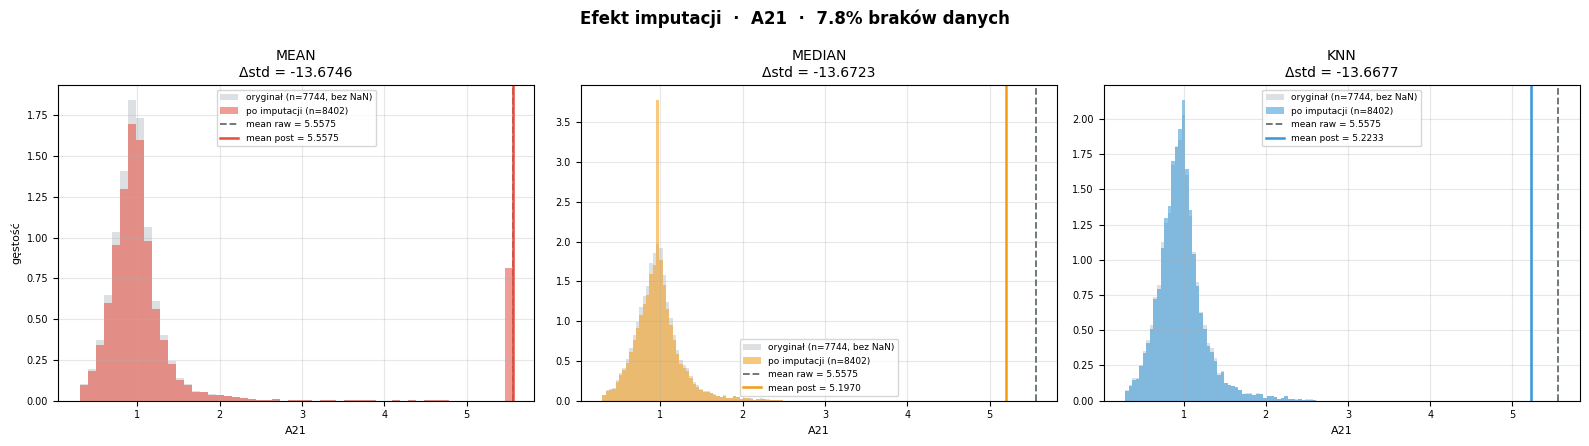

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
raw_miss = X_train[feat_miss].dropna().values
IMP_COLORS = {"mean": "#e74c3c", "median": "#f39c12", "knn": "#3498db"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(
    f"Efekt imputacji  ·  {feat_miss}  ·  {_nan[feat_miss]:.1%} braków danych",
    fontsize=12, fontweight="bold"
)
for ax, (imp_name, color) in zip(axes, IMP_COLORS.items()):
    lk   = f"{imp_name} | none | none | logistic_regression"
    vals = transformed_data[lk][0][:, fidx_miss]

    lo95, hi95 = np.percentile(vals, [1, 99])
    r_clip = raw_miss[(raw_miss >= lo95) & (raw_miss <= hi95)]
    v_clip = vals[(vals >= lo95) & (vals <= hi95)]
    bins   = np.linspace(lo95, hi95, 55)

    ax.hist(r_clip, bins=bins, density=True, alpha=0.5, color="#bdc3c7",
            label=f"oryginał (n={len(raw_miss)}, bez NaN)")
    ax.hist(v_clip, bins=bins, density=True, alpha=0.55, color=color,
            label=f"po imputacji (n={len(vals)})")
    ax.axvline(raw_miss.mean(), c="#636e72", ls="--", lw=1.3,
               label=f"mean raw = {raw_miss.mean():.4f}")
    ax.axvline(vals.mean(),     c=color,    ls="-",  lw=1.8,
               label=f"mean post = {vals.mean():.4f}")

    delta_std = vals.std() - np.nanstd(raw_miss)
    ax.set_title(f"{imp_name.upper()}\nΔstd = {delta_std:+.4f}", fontsize=10)
    ax.set_xlabel(feat_miss, fontsize=8)
    ax.set_ylabel("gęstość" if ax is axes[0] else "", fontsize=8)
    ax.legend(fontsize=6.5);  ax.tick_params(labelsize=7);  ax.grid(alpha=0.3)

plt.tight_layout();  plt.show()

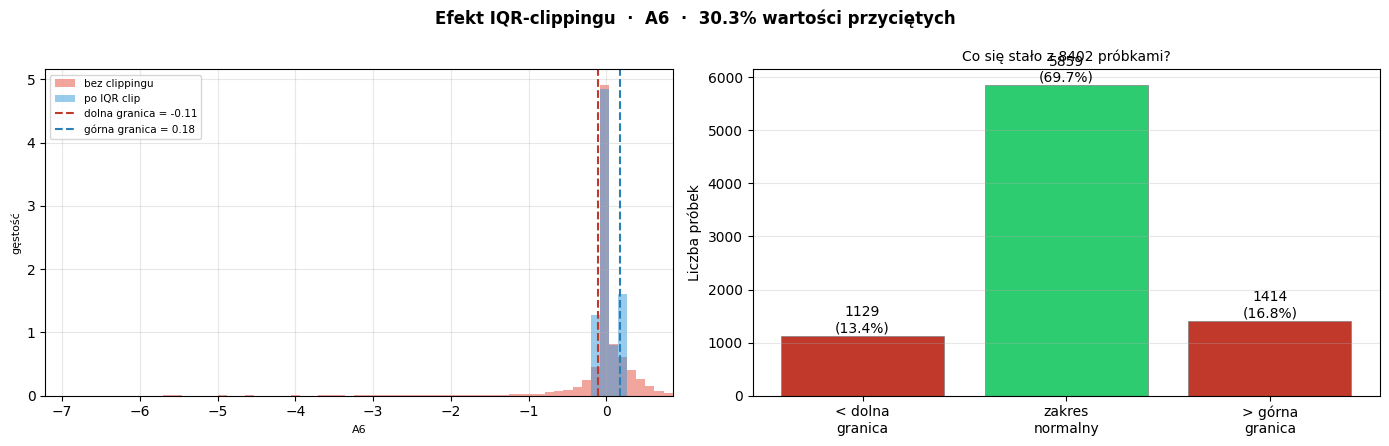

In [37]:


# ══════════════════════════════════════════════════════════════════════════════
# WYKRES 2 — Efekt IQR-clippingu
# Co dostaje "przycięte" i jak to zmienia rozkład?
# ══════════════════════════════════════════════════════════════════════════════
v_raw  = transformed_data["mean | none | none | logistic_regression"][0][:, fidx_out]
v_clip = transformed_data["mean | IQR_clip | none | logistic_regression"][0][:, fidx_out]

_Q1, _Q3 = np.percentile(v_raw, [25, 75])
clip_lo, clip_hi = _Q1 - 1.5*(_Q3-_Q1), _Q3 + 1.5*(_Q3-_Q1)
n_below  = int((v_raw < clip_lo).sum())
n_above  = int((v_raw > clip_hi).sum())
n_normal = len(v_raw) - n_below - n_above

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(
    f"Efekt IQR-clippingu  ·  {feat_out}  ·  {(n_below+n_above)/len(v_raw):.1%} wartości przyciętych",
    fontsize=12, fontweight="bold"
)
# KDE overlay
ax = axes[0]
lo_d, hi_d = np.percentile(v_raw, [0.2, 99])
bins = np.linspace(lo_d, hi_d, 70)
ax.hist(v_raw[(v_raw>=lo_d)&(v_raw<=hi_d)],  bins=bins, density=True,
        alpha=0.5, color="#e74c3c", label="bez clippingu")
ax.hist(v_clip[(v_clip>=lo_d)&(v_clip<=hi_d)], bins=bins, density=True,
        alpha=0.5, color="#3498db", label="po IQR clip")
ax.axvline(clip_lo, c="#c0392b", ls="--", lw=1.5, label=f"dolna granica = {clip_lo:.2f}")
ax.axvline(clip_hi, c="#2980b9", ls="--", lw=1.5, label=f"górna granica = {clip_hi:.2f}")
ax.set_xlabel(feat_out, fontsize=8);  ax.set_ylabel("gęstość", fontsize=8)
ax.legend(fontsize=7.5);  ax.grid(alpha=0.3);  ax.set_xlim(lo_d, hi_d)

# Bar chart: co się stało z każdą próbką
ax = axes[1]
bars_obj = ax.bar(
    ["< dolna\ngranica", "zakres\nnormalny", "> górna\ngranica"],
    [n_below, n_normal, n_above],
    color=["#c0392b", "#2ecc71", "#c0392b"], edgecolor="grey", linewidth=0.5
)
for b, cnt in zip(bars_obj, [n_below, n_normal, n_above]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            f"{cnt}\n({cnt/len(v_raw):.1%})", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Liczba próbek")
ax.set_title(f"Co się stało z {len(v_raw)} próbkami?", fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout();  plt.show()

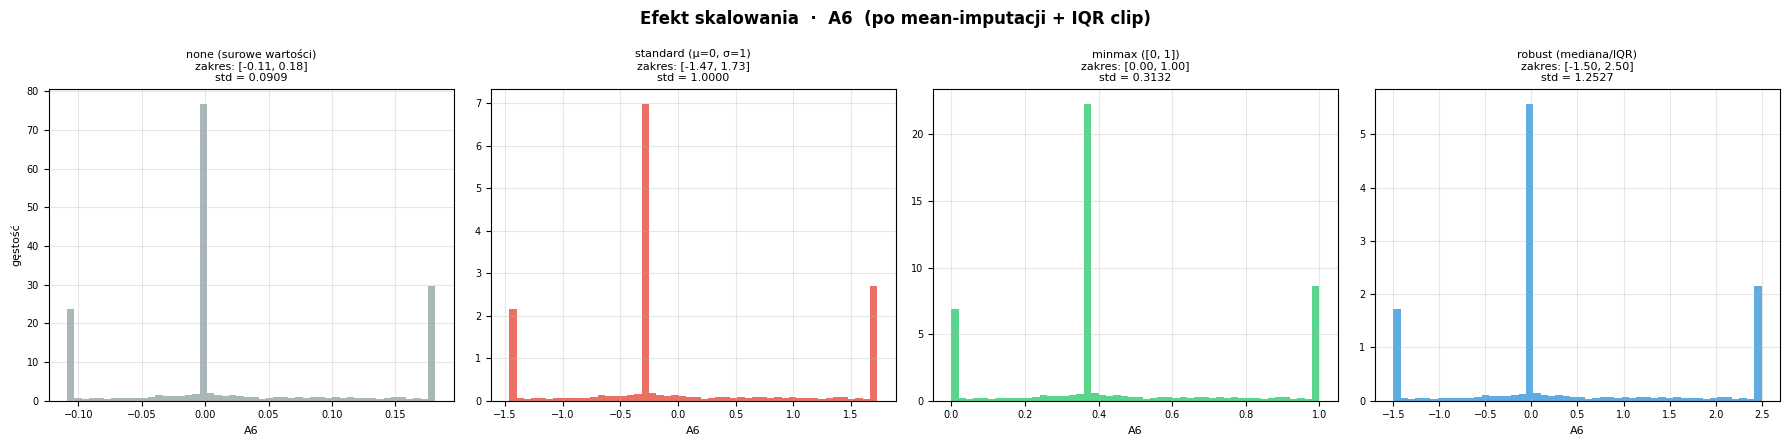

In [38]:


# ══════════════════════════════════════════════════════════════════════════════
# WYKRES 3 — Efekt skalowania
# Kształt się nie zmienia — zmienia się tylko zakres. Ale to ma znaczenie dla modeli.
# ══════════════════════════════════════════════════════════════════════════════
SCALER_MAP = [
    ("mean | IQR_clip | none | logistic_regression",     "none (surowe wartości)", "#95a5a6"),
    ("mean | IQR_clip | standard | logistic_regression", "standard (μ=0, σ=1)",   "#e74c3c"),
    ("mean | IQR_clip | minmax | logistic_regression",   "minmax ([0, 1])",        "#2ecc71"),
    ("mean | IQR_clip | robust | logistic_regression",   "robust (mediana/IQR)",   "#3498db"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle(
    f"Efekt skalowania  ·  {feat_out}  (po mean-imputacji + IQR clip)",
    fontsize=12, fontweight="bold"
)
for ax, (lk, scl_label, color) in zip(axes, SCALER_MAP):
    v = transformed_data[lk][0][:, fidx_out]
    lo_v, hi_v = np.percentile(v, [0.5, 99.5])
    ax.hist(v[(v>=lo_v)&(v<=hi_v)], bins=50, density=True, color=color, alpha=0.8)
    ax.set_title(f"{scl_label}\nzakres: [{lo_v:.2f}, {hi_v:.2f}]\nstd = {v.std():.4f}", fontsize=8)
    ax.set_xlabel(feat_out, fontsize=8)
    ax.set_ylabel("gęstość" if ax is axes[0] else "", fontsize=8)
    ax.tick_params(labelsize=7);  ax.grid(alpha=0.3)

plt.tight_layout();  plt.show()


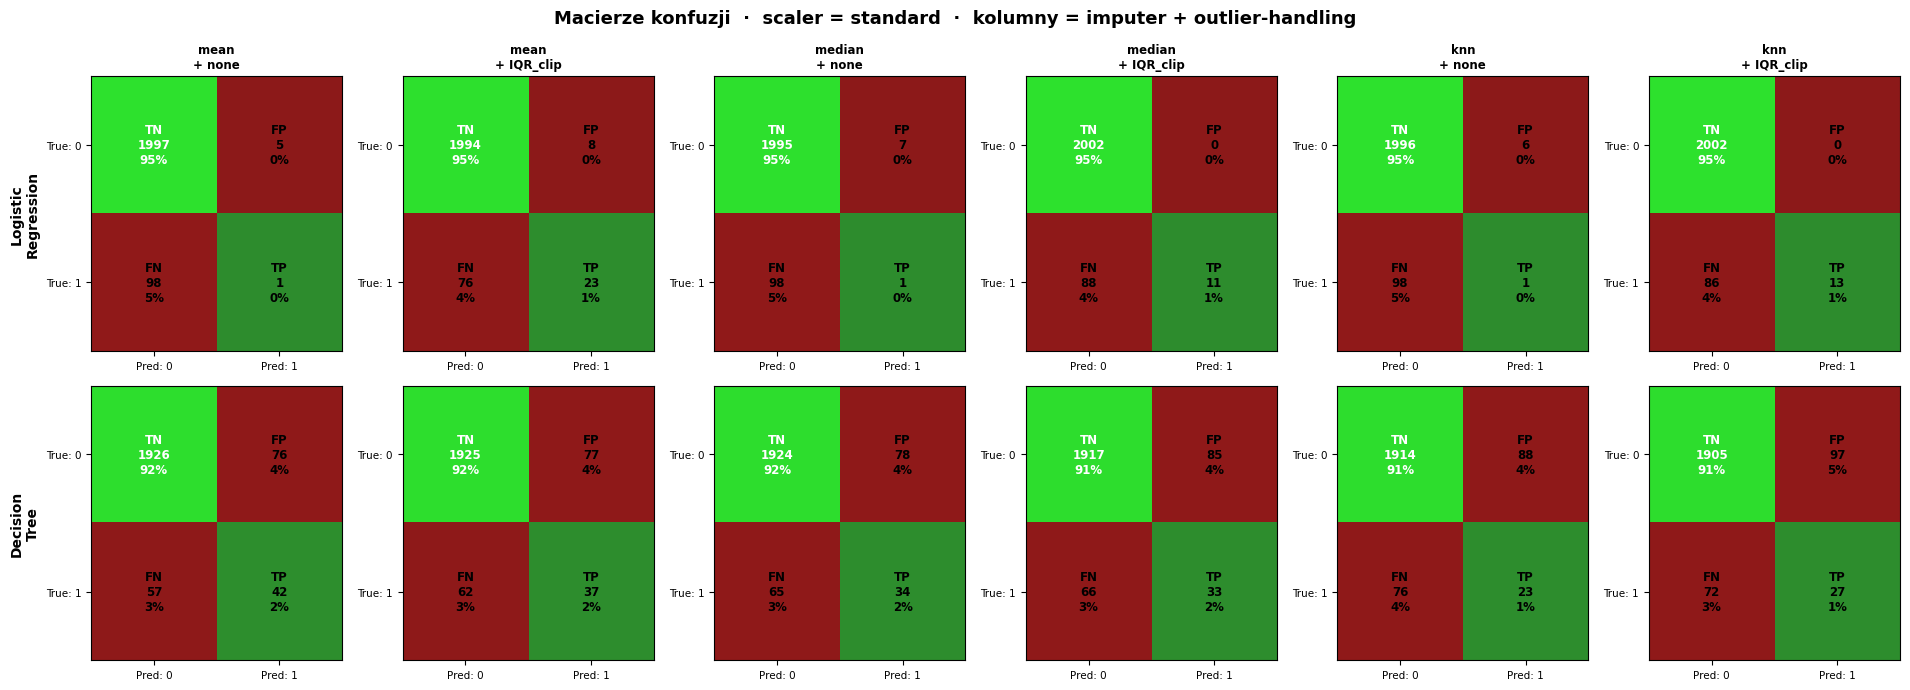

In [39]:

# ════════════════════════════════════════════════════════════════════════════
# Macierze konfuzji — imputer × outlier × model  (scaler = standard)
# ════════════════════════════════════════════════════════════════════════════
def cm_from_report(report):
    """Rekonstruuje [[TN, FP], [FN, TP]] z classification_report(output_dict=True)."""
    keys = sorted(k for k in report if k not in ("accuracy", "macro avg", "weighted avg"))
    c0, c1 = report[keys[0]], report[keys[1]]
    TP = int(round(c1["recall"] * c1["support"]))
    FN = max(0, int(c1["support"]) - TP)
    TN = int(round(c0["recall"] * c0["support"]))
    FP = max(0, int(c0["support"]) - TN)
    return np.array([[TN, FP], [FN, TP]])


FIXED_SCALER = "standard"
imp_list   = list(IMPUTERS.keys())
out_list   = list(OUTLIERS.keys())
model_list = list(MODELS.keys())

cm_lookup = {
    (r["imputer"], r["outlier"], r["scaler"], r["model"]): cm_from_report(r["conf_matrix"])
    for r in results
}

n_cols = len(imp_list) * len(out_list)
fig, axes = plt.subplots(len(model_list), n_cols, figsize=(n_cols * 3.2, 7))
fig.suptitle(
    f"Macierze konfuzji  ·  scaler = {FIXED_SCALER}  ·  kolumny = imputer + outlier-handling",
    fontsize=13, fontweight="bold"
)

col_labels = [f"{imp}\n+ {out}" for imp in imp_list for out in out_list]

for r_idx, mdl_name in enumerate(model_list):
    col_idx = 0
    for imp_name in imp_list:
        for out_name in out_list:
            ax = axes[r_idx][col_idx]
            cm = cm_lookup[(imp_name, out_name, FIXED_SCALER, mdl_name)]
            n_total = cm.sum()
            cm_pct  = cm / n_total

            # custom color: green diagonal, red off-diagonal — intensity = proportion
            img = np.zeros((2, 2, 4))
            for i in range(2):
                for j in range(2):
                    p = float(cm_pct[i, j])
                    if i == j:       # correct prediction
                        img[i,j] = [0.18, 0.55+0.35*p, 0.18, 1]
                    else:            # error
                        img[i,j] = [0.55+0.35*p, 0.1, 0.1, 1]

            ax.imshow(img, aspect="auto")

            cell_txt = [
                [f"TN\n{cm[0,0]}\n{cm_pct[0,0]:.0%}", f"FP\n{cm[0,1]}\n{cm_pct[0,1]:.0%}"],
                [f"FN\n{cm[1,0]}\n{cm_pct[1,0]:.0%}", f"TP\n{cm[1,1]}\n{cm_pct[1,1]:.0%}"],
            ]
            for i in range(2):
                for j in range(2):
                    ax.text(j, i, cell_txt[i][j], ha="center", va="center",
                            fontsize=8.5, fontweight="bold",
                            color="white" if cm_pct[i,j] > 0.25 else "black")

            if r_idx == 0:
                ax.set_title(col_labels[col_idx], fontsize=8.5, fontweight="bold")
            if col_idx == 0:
                lbl = "Logistic\nRegression" if "logistic" in mdl_name else "Decision\nTree"
                ax.set_ylabel(lbl, fontsize=10, fontweight="bold")

            ax.set_xticks([0, 1]);  ax.set_xticklabels(["Pred: 0", "Pred: 1"], fontsize=7.5)
            ax.set_yticks([0, 1]);  ax.set_yticklabels(["True: 0", "True: 1"], fontsize=7.5, rotation=0)
            col_idx += 1

plt.tight_layout()
plt.show()


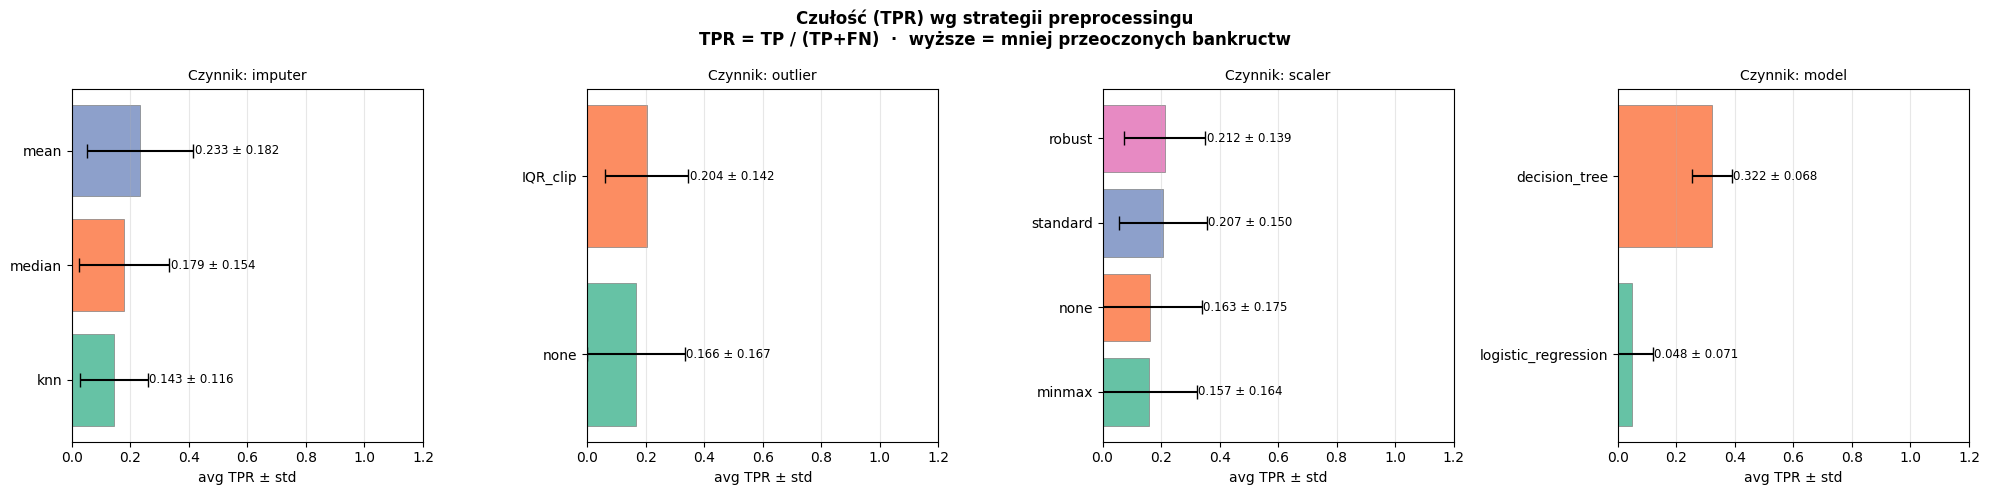

In [40]:

# ════════════════════════════════════════════════════════════════════════════
# Połączenie: rozkład danych → wynik klasyfikatora
# TPR (czułość) = jak wiele bankructw udało się wykryć?
# W tym problemie FN to "przeoczone bankructwo" — najkosztowniejszy błąd.
# ════════════════════════════════════════════════════════════════════════════
tpr_rows = []
for r in results:
    cm = cm_from_report(r["conf_matrix"])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    tpr_rows.append({
        "imputer": r["imputer"],
        "outlier": r["outlier"],
        "scaler":  r["scaler"],
        "model":   r["model"],
        "TPR": TP / (TP + FN) if (TP + FN) > 0 else 0.0,
        "FPR": FP / (FP + TN) if (FP + TN) > 0 else 0.0,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
    })
df_tpr = pd.DataFrame(tpr_rows)

# ── PANEL A: TPR per factor level ────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    "Czułość (TPR) wg strategii preprocessingu\n"
    "TPR = TP / (TP+FN)  ·  wyższe = mniej przeoczonych bankructw",
    fontsize=12, fontweight="bold"
)
for ax, factor in zip(axes, ["imputer", "outlier", "scaler", "model"]):
    stats = df_tpr.groupby(factor)["TPR"].agg(["mean", "std"]).reset_index()
    stats = stats.sort_values("mean", ascending=True).reset_index(drop=True)
    palette = sns.color_palette("Set2", len(stats))
    for i, row in stats.iterrows():
        ax.barh(row[factor], row["mean"], xerr=row["std"],
                color=palette[i], capsize=5, edgecolor="grey", linewidth=0.5)
        ax.text(row["mean"] + row["std"] + 0.005, i,
                f'{row["mean"]:.3f} ± {row["std"]:.3f}', va="center", fontsize=8.5)
    ax.set_title(f"Czynnik: {factor}", fontsize=10)
    ax.set_xlabel("avg TPR ± std")
    ax.set_xlim(0, 1.2)
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

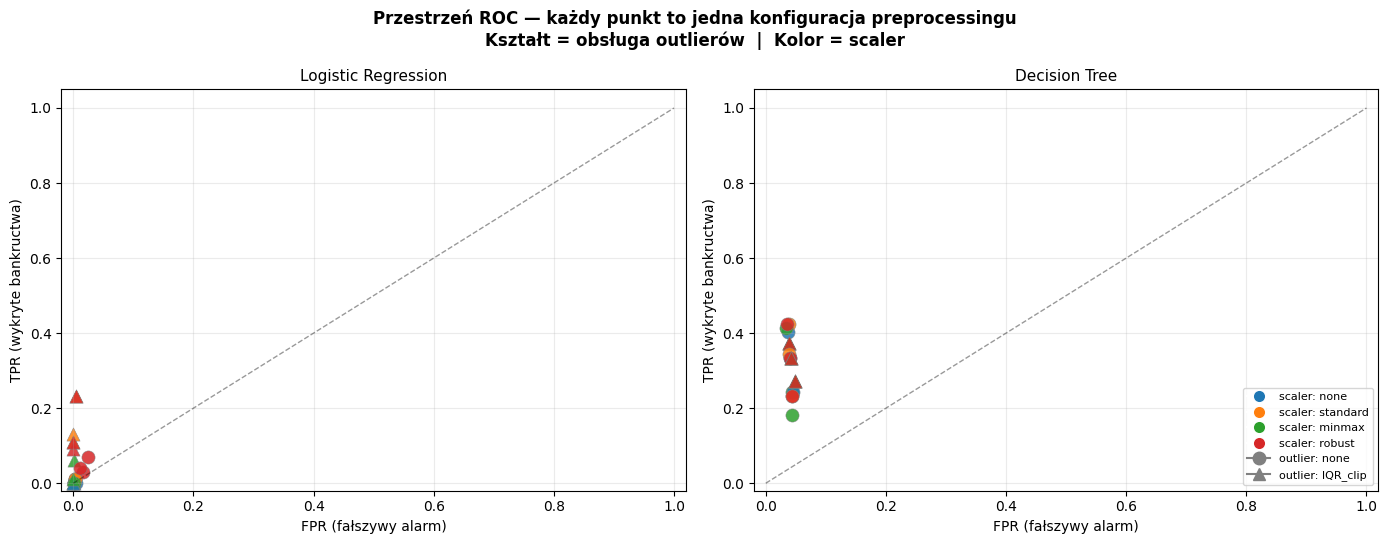

In [41]:

# ── PANEL B: Przestrzeń ROC — preprocessing jako źródło rozrzutu ──────────
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    "Przestrzeń ROC — każdy punkt to jedna konfiguracja preprocessingu\n"
    "Kształt = obsługa outlierów  |  Kolor = scaler",
    fontsize=12, fontweight="bold"
)
scaler_colors   = dict(zip(list(SCALERS.keys()), sns.color_palette("tab10", len(SCALERS))))
outlier_markers = {"none": "o", "IQR_clip": "^"}

for ax, mdl_name in zip(axes, model_list):
    sub = df_tpr[df_tpr["model"] == mdl_name]
    for _, point in sub.iterrows():
        ax.scatter(
            point["FPR"], point["TPR"],
            color=scaler_colors[point["scaler"]],
            marker=outlier_markers[point["outlier"]],
            s=90, alpha=0.85, edgecolors="grey", linewidth=0.4
        )
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
    ax.set_title(mdl_name.replace("_", " ").title(), fontsize=11)
    ax.set_xlabel("FPR (fałszywy alarm)");  ax.set_ylabel("TPR (wykryte bankructwa)")
    ax.grid(alpha=0.25);  ax.set_xlim(-0.02, 1.02);  ax.set_ylim(-0.02, 1.05)

legend_handles = (
    [Line2D([0],[0], marker="o", color="w", markerfacecolor=c, markersize=9, label=f"scaler: {s}")
     for s, c in scaler_colors.items()] +
    [Line2D([0],[0], marker=m, color="grey", markersize=9, label=f"outlier: {o}")
     for o, m in outlier_markers.items()]
)
axes[1].legend(handles=legend_handles, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()


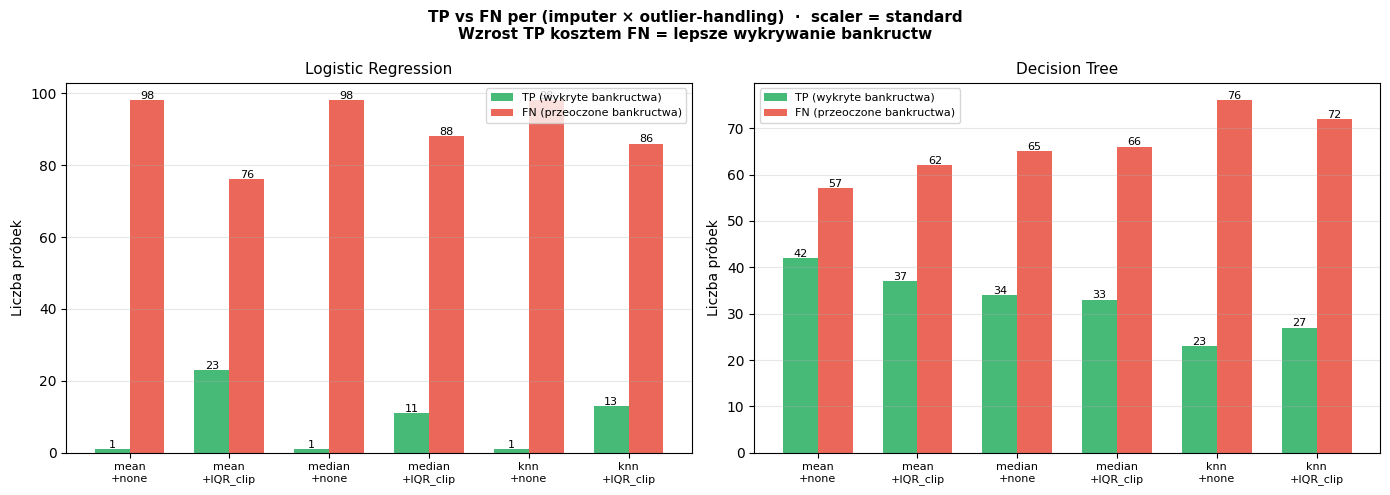

In [42]:


# ── PANEL C: TP vs FN per (imputer × outlier) — scaler=standard ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "TP vs FN per (imputer × outlier-handling)  ·  scaler = standard\n"
    "Wzrost TP kosztem FN = lepsze wykrywanie bankructw",
    fontsize=11, fontweight="bold"
)
for ax, mdl_name in zip(axes, model_list):
    sub = df_tpr[(df_tpr["model"] == mdl_name) & (df_tpr["scaler"] == FIXED_SCALER)].reset_index(drop=True)
    x_labels = [f"{r['imputer']}\n+{r['outlier']}" for _, r in sub.iterrows()]
    x = np.arange(len(x_labels))
    width = 0.35
    ba = ax.bar(x - width/2, sub["TP"], width, label="TP (wykryte bankructwa)",   color="#27ae60", alpha=0.85)
    bb = ax.bar(x + width/2, sub["FN"], width, label="FN (przeoczone bankructwa)", color="#e74c3c", alpha=0.85)
    for bar_obj, col in [(ba, "TP"), (bb, "FN")]:
        for b, v in zip(bar_obj, sub[col]):
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, str(int(v)),
                    ha="center", fontsize=8)
    ax.set_xticks(x);  ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_title(mdl_name.replace("_", " ").title(), fontsize=11)
    ax.set_ylabel("Liczba próbek")
    ax.legend(fontsize=8);  ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
